# Success Probability Modelling
### Green: Fit GPR for Birdie Probability
- from each point, compute the probability of birdieing that is $$\mathbb{P}(outcome =1)$$ and then fit a gpr,

Then for approach shot location for all club aimpoints we simulate landing points and if not on green then ignore since they won't birdie (we assume they don't). Then choose the best club aim and fit a 2nd gpr and so on.

## Plotting Hole

/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_22261/1535218924.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column
/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_22261/1535218924.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["dist_to_green"] = teeboxes["centroid"].apply(


Original fairway centroid: POINT (428316.7204142687 3771582.6458220687)
Shifting by x: -428316.7204, y: -3771482.6458


<Axes: title={'center': 'Par 4 Strategy Layout'}>

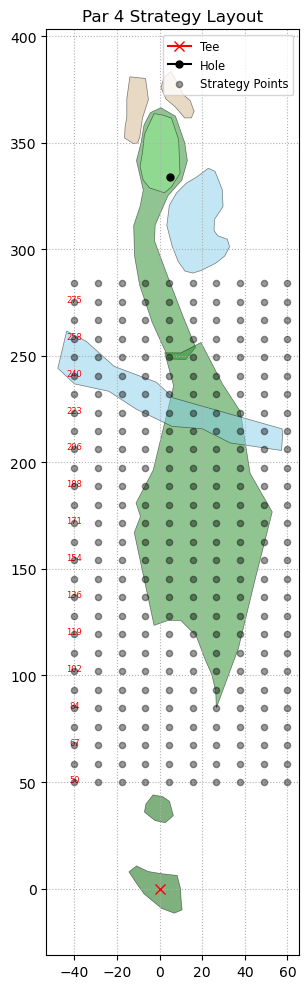

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point


hole_9 = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")

hole = (5, 174)

hole_9["geometry"] = hole_9["WKT"].apply(wkt.loads)

def get_centroid(row):
    shape = wkt.loads(row["WKT"])
    return shape.centroid.coords[0] # returns the x,y coords

# finding furthest teebox
teeboxes = hole_9[hole_9["lie"].str.contains("tee", case = False)]
green = hole_9[hole_9["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green["WKT"])
green_centre = get_centroid(green)
# getting different teeboxes centre
teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column

# distances to green
teeboxes["dist_to_green"] = teeboxes["centroid"].apply(
    # np.array(pt) - np.array(green_centre) -> subtracts the two 2d points, and linalg compute the euclidean distance
    lambda pt: np.linalg.norm(np.array(pt) - np.array(green_centre))
)

longest_teebox = teeboxes.loc[teeboxes["dist_to_green"].idxmax()]
tee_point = longest_teebox["centroid"]

## ------------- Extension
gdf = gpd.read_file("/Users/federicadomecq/Documents/golfModeL47-1/PART 3 / Simulating Par 4/newshapes.geojson")

# Filter by terrain type
new_fairway = gdf[gdf["lie"] == "fairway"]
new_hazard1 = gdf[gdf["lie"] == "water_hazard_1"]
new_hazard2 = gdf[gdf["lie"] == "water_hazard_2"]
new_hazard3 = gdf[gdf["lie"] == "water_hazard_3"]

#converting to metres
new_fairway = new_fairway.to_crs(epsg=32611)
new_hazard1 = new_hazard1.to_crs(epsg=32611)
new_hazard2 = new_hazard2.to_crs(epsg=32611)
new_hazard3 = new_hazard3.to_crs(epsg=32611)

# Convert to shapely for simulation
fairway_shapes2 = new_fairway["geometry"].tolist()
water_shape1 = new_hazard1["geometry"].tolist()
water_shape2 = new_hazard2["geometry"].tolist()
water_shape3 = new_hazard3["geometry"].tolist()

# weird fix
from shapely.affinity import translate

# Get the centroid of the new fairway (in lat/lon)
ref_centroid = new_fairway.iloc[0].geometry.centroid
print("Original fairway centroid:", ref_centroid)

#  target location — 
target_x, target_y = 0, 100

# Calculate the amount to shift
x_shift = target_x - ref_centroid.x
y_shift = target_y - ref_centroid.y
print(f"Shifting by x: {x_shift:.4f}, y: {y_shift:.4f}")

# Apply the shift to all geometries
def shift_geometry(geom):
    return translate(geom, xoff=x_shift, yoff=y_shift)

new_fairway["geometry"] = new_fairway["geometry"].apply(shift_geometry)
new_hazard1["geometry"] = new_hazard1["geometry"].apply(shift_geometry)
new_hazard2["geometry"] = new_hazard2["geometry"].apply(shift_geometry)
new_hazard3["geometry"] = new_hazard3["geometry"].apply(shift_geometry)

# ---------- rotating shapes - to be in the same direction as hole

from shapely.affinity import rotate

# Get the bounds of the fairway polygon
fairway_poly = new_fairway.iloc[0].geometry
minx, miny, maxx, maxy = fairway_poly.bounds

# Get two points to define direction
start = np.array([fairway_poly.centroid.x, miny])  # bottom
end = np.array([fairway_poly.centroid.x, maxy])    # top

# Direction vector
vec = end - start

# Angle with respect to the y-axis (0, 1)
angle_rad = np.arctan2(vec[0], vec[1])  # we flip x and y to get angle from y-axis
angle_deg = np.degrees(angle_rad)

def rotate_geometry(geom, angle, origin="centroid"):
    return rotate(geom, angle=-angle, origin=origin, use_radians=False)

# Apply rotation
rotation_angle = angle_deg  # from step 1 above
new_fairway["geometry"] = new_fairway["geometry"].apply(rotate_geometry, args=(rotation_angle,))
new_hazard1["geometry"] = new_hazard1["geometry"].apply(rotate_geometry, args=(rotation_angle,))
new_hazard2["geometry"] = new_hazard2["geometry"].apply(rotate_geometry, args=(rotation_angle,))
new_hazard3["geometry"] = new_hazard3["geometry"].apply(rotate_geometry, args=(rotation_angle,))

#  downstream shapes (green, bunkers, existing water hazard) -> shifting up
shift_targets = hole_9[hole_9["lie"].isin(["green", "bunker", "water_hazard", "fairway"])].copy()

y_shift = 160

hole = (5, 174 + y_shift)

def shift_wkt(wkt_str):
    shape = wkt.loads(wkt_str)
    return translate(shape, yoff=y_shift)

# Apply shift
hole_9.loc[shift_targets.index, "WKT"] = shift_targets["WKT"].apply(shift_wkt).apply(lambda g: g.wkt)

from shapely.affinity import translate, rotate

# --- Fairway extension ----------------------
fairway_centroid = new_fairway.iloc[0].geometry.centroid
target_x, target_y = 20, 175
x_shift = target_x - fairway_centroid.x
y_shift = target_y - fairway_centroid.y

new_fairway["geometry"] = new_fairway["geometry"].apply(
    lambda geom: translate(geom, xoff=x_shift, yoff=y_shift)
)

new_fairway["geometry"] = new_fairway["geometry"].apply(
    lambda geom: rotate(geom, angle=-68, origin="centroid", use_radians=False)
)

# --- Hazard 3 addition --------------
hazard3_centroid = new_hazard3.iloc[0].geometry.centroid
target_x3, target_y3 = 0, 230
x3_shift = target_x3 - hazard3_centroid.x
y3_shift = target_y3 - hazard3_centroid.y

new_hazard3["geometry"] = new_hazard3["geometry"].apply(
    lambda geom: translate(geom, xoff=x3_shift, yoff=y3_shift)
)

new_hazard3["geometry"] = new_hazard3["geometry"].apply(
    lambda geom: rotate(geom, angle=110, origin="centroid", use_radians=False)
)

import matplotlib.pyplot as plt
from shapely import wkt


# for plotting where the approach shots are evaluated
hole_vec = np.array(hole)
tee_vec= np.array(tee_point)
hole_to_tee_vec = hole_vec - tee_vec
ht_length = np.linalg.norm(hole_to_tee_vec)

# Grid parameters
x_vals = np.linspace(-40, 60, int(100 / 10 ) ) # evaluating at 10 yard intervals
y_vals = np.linspace(50, ht_length - 50, int((ht_length - 50) / 10 ))

strategy_points2 = [(x, y) for y in y_vals for x in x_vals]

def plot_hole_layout(hole_geom_df, new_fairway=None, new_hazards=None,
                     tee_point=None, hole_point=None, fairway_grid=None,
                     title="Hole Layout", figsize=(10, 10), lie_colors=None, plot_approach = True):

    if lie_colors is None:
        lie_colors = {
            "bunker": "tan",
            "fairway": "forestgreen",
            "new_fairway": "forestgreen",
            "green": "lightgreen",
            "OB": "lightcoral",
            "rough": "mediumseagreen",
            "tee": "darkgreen",
            "water_hazard": "skyblue",
            "new_hazard1": "skyblue",
            "new_hazard2": "skyblue",
            "new_hazard3": "skyblue"
        }

    fig, ax = plt.subplots(figsize=figsize)

    # Base geometry (from WKT)
    for _, row in hole_geom_df.iterrows():
        geom = wkt.loads(row["WKT"])
        color = lie_colors.get(row["lie"], "lightgrey")

        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)

    # Optional new fairway
    if new_fairway is not None:
        for _, row in new_fairway.iterrows():
            x, y = row["geometry"].exterior.xy
            ax.fill(x, y, alpha=0.5, fc=lie_colors["new_fairway"], edgecolor="black", linewidth=0.5)

    # Optional new hazards
    if new_hazards:
        for i, hazard_df in enumerate(new_hazards, start=1):
            key = f"new_hazard{i}"
            if key in lie_colors:
                for _, row in hazard_df.iterrows():
                    x, y = row["geometry"].exterior.xy
                    ax.fill(x, y, alpha=0.5, fc=lie_colors[key], edgecolor="black", linewidth=0.5)

    # Tee + Hole
    if tee_point:
        ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=7, label="Tee")
    if hole_point:
        ax.plot(hole_point[0], hole_point[1], marker='o', color='black', markersize=5, label="Hole")

    if plot_approach:
        ax = plt.gca()
        # Plot points
        xs, ys = zip(*strategy_points2)
        ax.scatter(xs, ys, color='black', s=20, label="Strategy Points", zorder=10, alpha= .4)

        # Optional: label some for visual debug
        for x, y in strategy_points2[::20]:
            ax.text(x, y, f"{int(y)}", fontsize=6, color='red', ha='center')

        ax.legend()
        plt.draw()

    ax.set_aspect("equal")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize="small")
    ax.grid(True, linestyle=':')
    plt.tight_layout()
    #plt.show()
    return ax

plot_hole_layout(
    hole_geom_df=hole_9,
    new_fairway=new_fairway,
    new_hazards=[new_hazard3],
    tee_point=tee_point,
    hole_point=hole,
    title="Par 4 Strategy Layout",
    plot_approach= True
)


## Putting Logic / Birdie and GPR

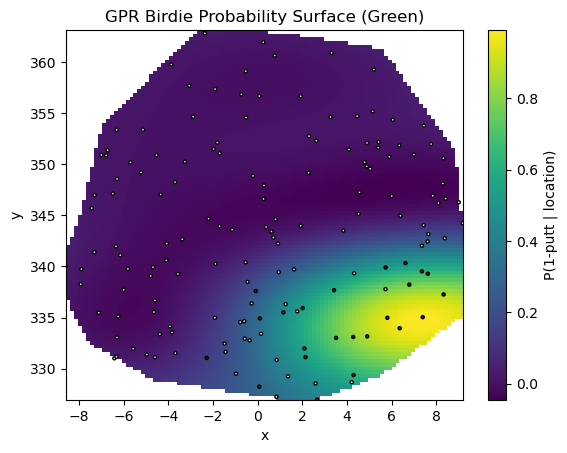

In [4]:
import torch
import gpytorch

putts_og_loc = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 3 / Simulating Par 4/gpr_green_dataset.csv")
shifted_putts = putts_og_loc.copy()
shifted_putts["y"] = shifted_putts["y"] + 160
shifted_putts["birdie"] = (shifted_putts["simulated_strokes"] == 1).astype(float)

# Prepare training data
X_train = torch.tensor(shifted_putts[["x", "y"]].values, dtype=torch.float32)
y_train = torch.tensor(shifted_putts["birdie"].values, dtype=torch.float32)

# GP model for birdie probability
class GPModelBirdie(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPModelBirdie(X_train, y_train, likelihood)

model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
for i in range(100):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()
model.eval()
likelihood.eval()

# Extract green polygon after shifting
green_row = hole_9[hole_9["lie"] == "green"].iloc[0]
green_polygon = wkt.loads(green_row["WKT"])

# Grid for surface plot
xg = np.linspace(shifted_putts["x"].min(), shifted_putts["x"].max(), 100)
yg = np.linspace(shifted_putts["y"].min(), shifted_putts["y"].max(), 100)
grid = np.array([[x, y] for y in yg for x in xg])
X_grid = torch.tensor(grid, dtype=torch.float32)

with torch.no_grad():
    preds = likelihood(model(X_grid)).mean.numpy().reshape(len(yg), len(xg))

# Mask points outside green 
def point_in_green(pt, green_polygon):
    if green_polygon.geom_type == "Polygon":
        return green_polygon.contains(pt)
    elif green_polygon.geom_type == "MultiPolygon":
        return any(poly.contains(pt) for poly in green_polygon.geoms)
    return False

mask = np.array([point_in_green(Point(x, y), green_polygon) for y in yg for x in xg])
masked_preds = np.full(preds.shape, np.nan)
flat_preds = preds.flatten()
masked_preds_flat = np.where(mask, flat_preds, np.nan)
masked_preds = masked_preds_flat.reshape(preds.shape)

plt.imshow(masked_preds, extent=[xg.min(), xg.max(), yg.min(), yg.max()],
           origin="lower", cmap="viridis", aspect="auto")
plt.colorbar(label="P(1-putt | location)")
plt.scatter(shifted_putts["x"], shifted_putts["y"], c=shifted_putts["birdie"], s=5, cmap="Greens", edgecolor='k')
plt.title("GPR Birdie Probability Surface (Green)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## Function for 1 putt on green prob calc

In [5]:

def p_1putt_on_green(point, model, likelihood, green_polygon):
    pt = Point(point)
    # Robust check for Polygon or MultiPolygon
    if green_polygon.geom_type == "Polygon":
        in_poly = green_polygon.contains(pt)
    elif green_polygon.geom_type == "MultiPolygon":
        in_poly = any(poly.contains(pt) for poly in green_polygon.geoms)
    else:
        in_poly = False

    if not in_poly:
        return 0.0

    model.eval()
    likelihood.eval()
    test_x = torch.tensor([[point[0], point[1]]], dtype=torch.float32)
    with torch.no_grad():
        pred = likelihood(model(test_x))
        # Clamp the output between 0 and 1
        p_1putt = float(np.clip(pred.mean.item(), 0, 1))
    return p_1putt

## Approach Shot Calculation

## Script4 Imports

/Users/federicadomecq/Documents/golfModeL47-1/PART 3 / Simulating Par 4/scriptpar4.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column
/Users/federicadomecq/Documents/golfModeL47-1/PART 3 / Simulating Par 4/scriptpar4.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["dist_to_green"] = teeboxes["centroid"].apply(


Original fairway centroid: POINT (428316.7204142687 3771582.6458220687)
Shifting by x: -428316.7204, y: -3771482.6458


/opt/anaconda3/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


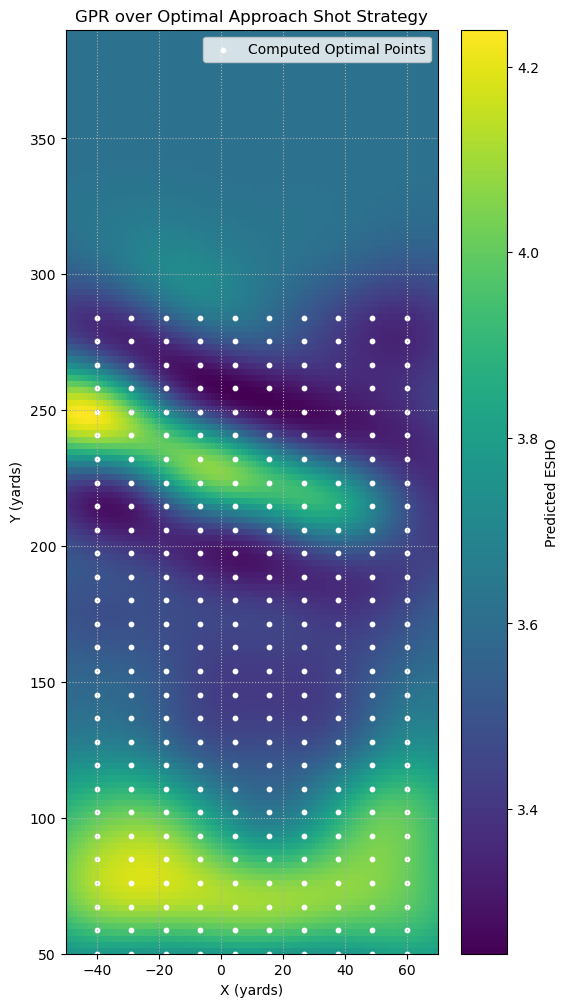

{'club': '5-wood', 'aim_offset': 6, 'mean': 3.3923685550689697, 'variance': 0.006741139905707314}


<Figure size 2000x1800 with 0 Axes>

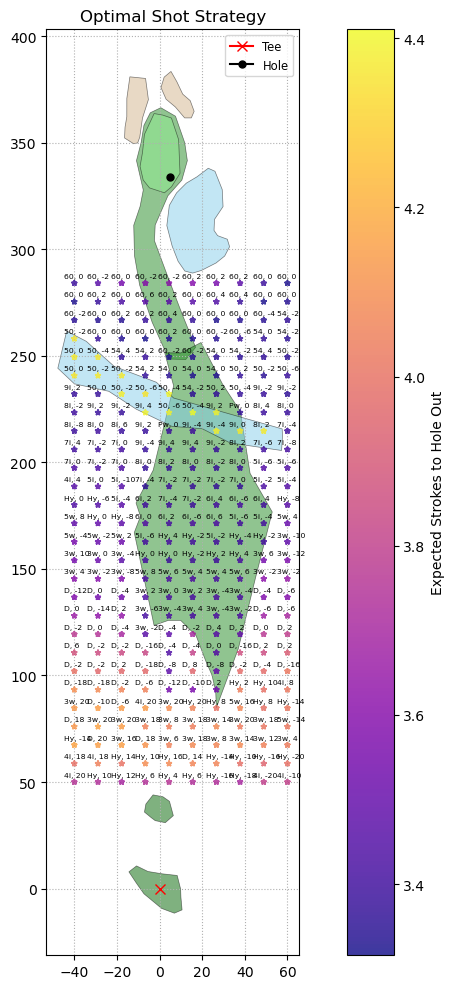

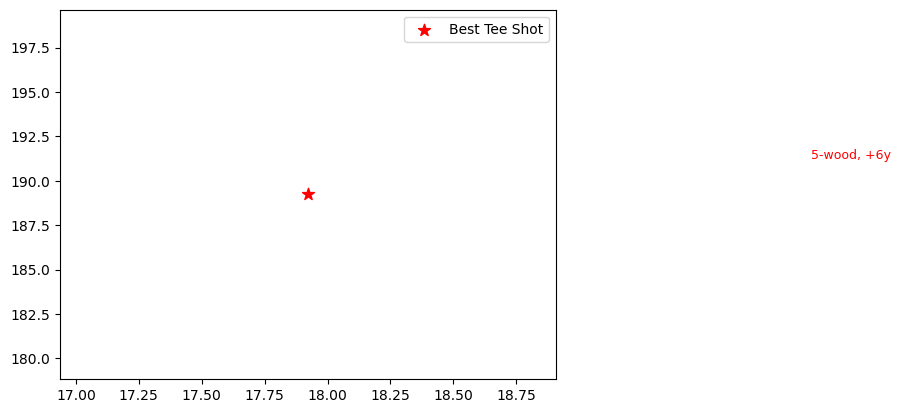

In [6]:
from scriptpar4 import (
    get_club_distribution,
    get_rough_distribution,
    get_lie_category,
    rotation_translator2,
    club_distributions,
    rough_distributions,  
    tee_point,
    hole,
    strategy_points,
    get_water_intersection # if using water logic
)

## Simulate and Evaluate

In [7]:
def simulate_and_evaluate_birdie(starting_point, target, club, aim_offset=0, n_samples=20, model=None, likelihood=None, green_polygon=None):
    
    starting_lie = get_lie_category(starting_point)
    if starting_lie == "rough":
        mu, cov = get_rough_distribution(club)
    else:
        mu, cov = get_club_distribution(club)
    raw_samples = np.random.multivariate_normal(mu, cov, size=n_samples)

    # Rotation setup
    total_distance = np.linalg.norm(np.array(target) - np.array(starting_point))
    angle_rad = np.arctan(aim_offset / total_distance)
    angle_deg = np.degrees(angle_rad)

    birdie_probs = []
    for shot in raw_samples:
        x_rot, y_rot = rotation_translator2(shot[0], shot[1], angle_deg, starting_point, target)
        landing = (x_rot, y_rot)
        # Use green-level GPR probability if on green, else 0
        p_birdie = p_1putt_on_green(landing, model, likelihood, green_polygon)
        birdie_probs.append(p_birdie)

    mean_birdie_prob = np.mean(birdie_probs) if birdie_probs else np.nan
    return {"birdie_probs": birdie_probs, "mean_birdie_prob": mean_birdie_prob}


## Grid Evaluation

In [8]:
def simulate_approach_shots_birdie(starting_points, clubs, target, aim_range=(-20, 20), aim_step=2, n_samples=50, model=None, likelihood=None, green_polygon=None):
    start, stop = aim_range
    aim_points = range(start, stop + 1, aim_step)
    clubs_avg_carry = {club: stats["mean"][1] for club, stats in club_distributions.items()}
    optimal_results = []

    for starting_point in starting_points:
        starting_lie = get_lie_category(starting_point)

        # If starting from water, probability of birdie is 0
        if starting_lie == "water":
            best_res = {
                "start": starting_point,
                "club": None,
                "aim_offset": None,
                "mean_birdie_prob": 0.0
            }
            optimal_results.append(best_res)
            continue  # skip to the next starting point

        # Normal logic for non-water starting points
        playing_location = starting_point
        total_distance = np.linalg.norm(np.array(target) - np.array(playing_location))

        club_diffs = [(club, abs(avg_carry - total_distance))
                      for club, avg_carry in clubs_avg_carry.items()]
        top_5_clubs = [club for club, _ in sorted(club_diffs, key=lambda x: x[1])[:5]]

        best_res = None
        for club in top_5_clubs:
            for aim_offset in aim_points:
                result = simulate_and_evaluate_birdie(
                    starting_point=playing_location,
                    target=target,
                    club=club,
                    aim_offset=aim_offset,
                    n_samples=n_samples,
                    model=model,
                    likelihood=likelihood,
                    green_polygon=green_polygon
                )
                if np.isnan(result["mean_birdie_prob"]):
                    continue
                if (best_res is None) or (result["mean_birdie_prob"] > best_res["mean_birdie_prob"]):
                    best_res = {
                        "start": starting_point,
                        "club": club,
                        "aim_offset": aim_offset,
                        "mean_birdie_prob": result["mean_birdie_prob"]
                    }
        if best_res:
            optimal_results.append(best_res)
    return optimal_results

optimal_points_birdie = simulate_approach_shots_birdie(
    starting_points=strategy_points2,
    clubs=list(club_distributions.keys()),
    target=hole,
    aim_range=(-20, 20),
    aim_step=2,
    n_samples=50,
    model=model,
    likelihood=likelihood,
    green_polygon=green_polygon
)


<Figure size 2000x1800 with 0 Axes>

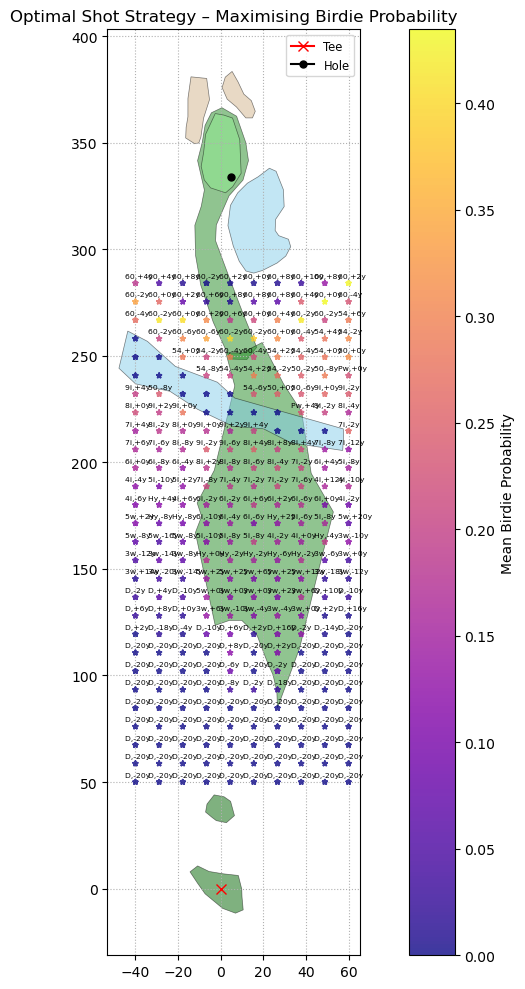

In [19]:
club_names = {
    'Driver':    {"short": "D",    "color": "#000000"},  # Black
    '3-wood':    {"short": "3w",   "color": "#FFAE00"},  # Orange
    '5-wood':    {"short": "5w",   "color": "#CC79A7"},  # Yellow
    'Hybrid':    {"short": "Hy",   "color": "#009E73"},  # Green
    '4 Iron':    {"short": "4i",   "color": "royalblue"},  # royal
    '5 Iron':    {"short": "5i",   "color": "#56B4E9"},  # Sky Blue
    '6 Iron':    {"short": "6i",   "color": "#4DAF4A"},  # Bright Green
    '7 Iron':    {"short": "7i",   "color": "#D55E00"},  # Reddish
    '8 Iron':    {"short": "8i",   "color": "#984EA3"},  # Purple
    '9 Iron':    {"short": "9i",   "color": "#FFEE00"},  # yellow
    'PW':        {"short": "Pw",   "color": "#0C034F"},  # Blue
    '50 deg':    {"short": "50",   "color": "#E41A1C"},  # Red
    '54 deg':    {"short": "54",   "color": "#999999"},  # Gray
    '60 deg':    {"short": "60",   "color": "#3E1F1F"},  # White
}

def plot_optimal_approaches(optimal_results, cmap="plasma", alpha=0.8, zorder=20):
    xs = [res["start"][0] for res in optimal_results]
    ys = [res["start"][1] for res in optimal_results]
    birdie_probs = [res["mean_birdie_prob"] for res in optimal_results]
    
    thin_space = "\u200B"
    labels = []

    for res in optimal_results:
        club_raw = res["club"]
        aim = res["aim_offset"]

        if club_raw is None or aim is None:
            labels.append("—")  # Skip label for invalid / water cases
            continue

        club_info = club_names.get(club_raw, {})
        short = club_info.get("short", club_raw)
        aim_fmt = int(aim) if abs(aim - int(aim)) < 1e-2 else round(aim, 1)
        labels.append(f"{short},{thin_space}{aim_fmt:+}y")

    plt.figure(figsize=(20, 18))

    # Plot background
    plot_hole_layout(
        hole_geom_df=hole_9,
        new_fairway=new_fairway,
        new_hazards=[new_hazard3],
        tee_point=tee_point,
        hole_point=hole,
        title="Optimal Shot Strategy – Maximising Birdie Probability",
        plot_approach=False
    )

    ax = plt.gca()
    scatter = ax.scatter(xs, ys, c=birdie_probs, marker=(5, 2), cmap=cmap, s=10, alpha=alpha, zorder=zorder)

    for i, (x, y, label) in enumerate(zip(xs, ys, labels)):
        if label != "—":
            ax.text(x - 5, y + 2.5, label, fontsize=5.5, color="black", zorder=zorder + 1)

    # Add colorbar for birdie probabilities
    cbar = plt.colorbar(scatter, ax=ax, label="Mean Birdie Probability")

plot_optimal_approaches(optimal_points_birdie)
plt.show()

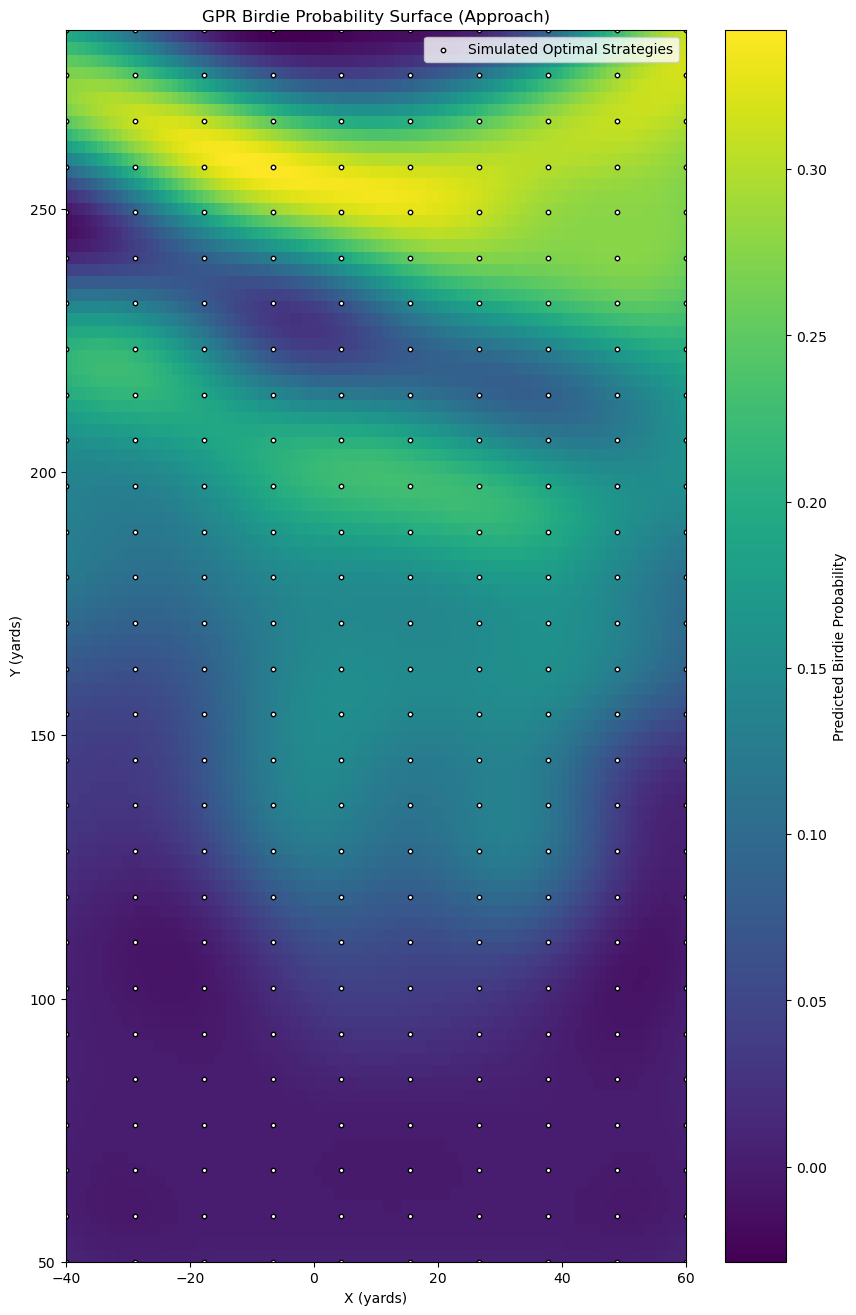

In [12]:
X_birdie = torch.tensor(
    [[res["start"][0], res["start"][1]] for res in optimal_points_birdie],
    dtype=torch.float32
)
y_birdie = torch.tensor(
    [res["mean_birdie_prob"] for res in optimal_points_birdie],
    dtype=torch.float32
)

import gpytorch

class GPModelApproachBirdie(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.covar_module.base_kernel.lengthscale = 15.0  # spacing

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

likelihood_surface = gpytorch.likelihoods.GaussianLikelihood()
model_surface = GPModelApproachBirdie(X_birdie, y_birdie, likelihood_surface)

model_surface.train()
likelihood_surface.train()
optimizer_surface = torch.optim.Adam(model_surface.parameters(), lr=0.1)
mll_surface = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_surface, model_surface)

for i in range(100):
    optimizer_surface.zero_grad()
    output = model_surface(X_birdie)
    loss = -mll_surface(output, y_birdie)
    loss.backward()
    optimizer_surface.step()

model_surface.eval()
likelihood_surface.eval()

# Define your plot grid
xg = np.linspace(min([res["start"][0] for res in optimal_points_birdie]),
                 max([res["start"][0] for res in optimal_points_birdie]), 100)
yg = np.linspace(min([res["start"][1] for res in optimal_points_birdie]),
                 max([res["start"][1] for res in optimal_points_birdie]), 100)
grid_points = torch.tensor([[x, y] for y in yg for x in xg], dtype=torch.float32)

with torch.no_grad():
    preds = likelihood_surface(model_surface(grid_points))
    pred_mean = preds.mean.numpy().reshape(len(yg), len(xg))


plt.figure(figsize=(10, 16))
plt.imshow(
    pred_mean, extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    origin="lower", cmap="viridis", aspect="auto"
)
plt.colorbar(label="Predicted Birdie Probability")
plt.scatter(
    X_birdie[:, 0], X_birdie[:, 1],
   s=10, color = "white", edgecolor='k', label="Simulated Optimal Strategies"
)
plt.xlabel("X (yards)")
plt.ylabel("Y (yards)")
plt.title("GPR Birdie Probability Surface (Approach)")
plt.legend()
plt.show()


In [23]:
def evaluate_tee_shot_b(tee_point, gpr_model, gpr_likelihood, aim_range=(-20, 20), aim_step=2, n_samples=30):
    best = None
    aim_offsets = range(aim_range[0], aim_range[1] + 1, aim_step)
    
    results = []

    for club in club_distributions:
        for aim in aim_offsets:
            mu, cov = get_club_distribution(club)
            samples = np.random.multivariate_normal(mu, cov, size=n_samples)

            evaluated_strokes = []

            for shot in samples:
                # Rotate to global coordinates
                x_rot, y_rot = rotation_translator2(shot[0], shot[1], aim, tee_point, hole)

                # Predict ESHO from the GPR model
                input_tensor = torch.tensor([[x_rot, y_rot]], dtype=torch.float32)
                with torch.no_grad(), gpytorch.settings.fast_pred_var():
                    pred = gpr_likelihood(gpr_model(input_tensor))
                    esho = pred.mean.item()

                if not np.isnan(esho):
                    evaluated_strokes.append(esho)

            if evaluated_strokes:
                mean_esho = np.mean(evaluated_strokes)
                var_esho = np.var(evaluated_strokes)

                result = {
                    "club": club,
                    "aim_offset": aim,
                    "mean": mean_esho,
                    "variance": var_esho
                }

                results.append(result)

                if (best is None) or (mean_esho > best["mean"]):
                    best = result

    return best, results

best_tee_shot, all_tee_shots = evaluate_tee_shot_b(tee_point=tee_point, gpr_model=model_surface, gpr_likelihood=likelihood_surface, aim_range=(-30,30), aim_step=2, n_samples=1000)

print(best_tee_shot)

{'club': '3-wood', 'aim_offset': 2, 'mean': 0.18594189369678496, 'variance': 0.0016675893197519193}


<Figure size 2000x1800 with 0 Axes>

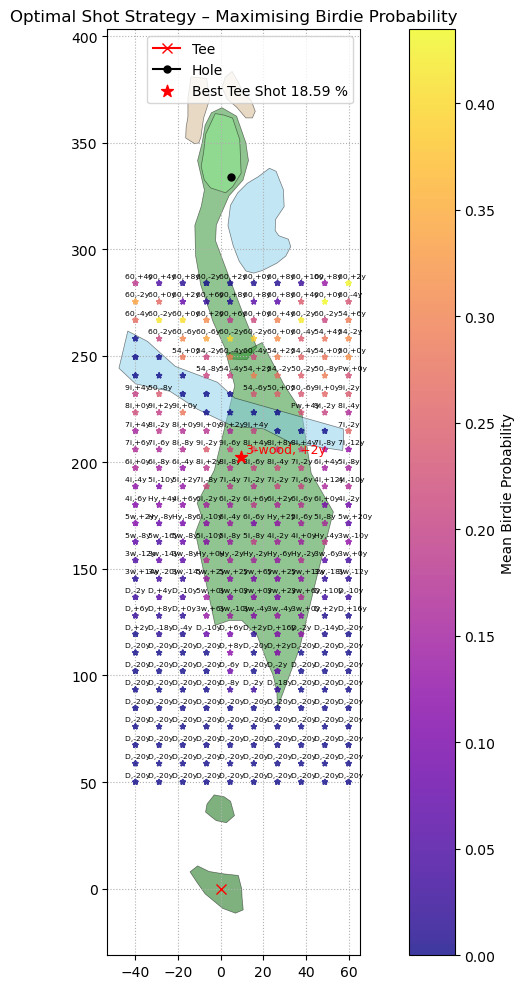

In [29]:
def truncate_float(float_number, decimal_places):
    multiplier = 10 ** decimal_places
    return int(float_number * multiplier) / multiplier

def plot_best_tee_shot(best_tee_shot, title="Best Tee Shot for Birdie Odds", zorder=100000):

    # Unpack best shot details
    club = best_tee_shot["club"]
    offset = best_tee_shot["aim_offset"]
    odds = truncate_float(best_tee_shot["mean"] * 100,2)

    # Get mean shot shape for the club
    mu = club_distributions[club]["mean"]

    # Compute rotated landing location
    x_rot, y_rot = rotation_translator2(
        mu[0], mu[1],
        offset,
        starting_point=tee_point,
        target=hole
    )

    # Plot hole background
    # plot_hole_layout(
    #     hole_geom_df=hole_9,
    #     new_fairway=new_fairway,
    #     new_hazards=[new_hazard3],
    #     tee_point=tee_point,
    #     hole_point=hole,
    #     title=title,
    #     plot_approach=True
    # )
    plot_optimal_approaches(optimal_points_birdie)

    ax = plt.gca()

    # Plot best tee shot landing location
    ax.scatter([x_rot], [y_rot], color="red", s=80, marker="*", label="Best Tee Shot" + f" {odds} %", zorder=zorder)

    # Annotate with club and aim offset
    label_text = f'{club}, {offset:+}y'
    ax.text(x_rot + 2, y_rot + 2, label_text, fontsize=9, color="red", zorder=zorder + 1)

    ax.legend(loc="upper right")
    plt.show()

plot_best_tee_shot(best_tee_shot)